In [2]:
import numpy as np
import pandas as pd
import torch 
import cv2
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import os
import h5py
from tqdm import tqdm
from torchvision.io import read_video
from transformers import VideoMAEFeatureExtractor, VideoMAEModel


c:\Users\Asus\AppData\Local\Programs\Python\Python38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
VIDEO_BASE_PATH = r"E:\nexar_dataset\train"
OUTPUT_PATH = r"E:\nexar_dataset\processed_frames"

meta_pos = pd.read_csv(r"E:\nexar_dataset\metadata1.csv")
meta_neg = pd.read_csv(r"E:\nexar_dataset\metadata2.csv")

meta_pos["target"] = 1
meta_neg["target"] = 0

train = pd.concat([meta_pos, meta_neg], ignore_index=True)

train["video_path"] = train.apply(
    lambda row: os.path.join(
        VIDEO_BASE_PATH,
        "positive" if row["target"] == 1 else "negative",
        row["file_name"]
    ),
    axis=1
)

train["id"] = range(len(train))

print(" shape:", train.shape)
print(train.head())


 shape: (1500, 10)
   file_name  time_of_event  time_of_alert light_conditions weather  \
0  00822.mp4         19.500         18.633           Normal  Cloudy   
1  00208.mp4         19.800         19.233           Normal  Cloudy   
2  00072.mp4         20.101         20.068           Normal   Clear   
3  00128.mp4         19.267         18.333           Normal   Clear   
4  00205.mp4         21.146         18.196           Normal   Clear   

       scene  time_to_accident  target  \
0      Urban               NaN       1   
1  Sub-urban               NaN       1   
2      Urban               NaN       1   
3      Urban               NaN       1   
4    Highway               NaN       1   

                                  video_path  id  
0  E:\nexar_dataset\train\positive\00822.mp4   0  
1  E:\nexar_dataset\train\positive\00208.mp4   1  
2  E:\nexar_dataset\train\positive\00072.mp4   2  
3  E:\nexar_dataset\train\positive\00128.mp4   3  
4  E:\nexar_dataset\train\positive\00205.mp4  

In [ ]:
test

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   file_name         1500 non-null   object 
 1   time_of_event     750 non-null    float64
 2   time_of_alert     750 non-null    float64
 3   light_conditions  1500 non-null   object 
 4   weather           1498 non-null   object 
 5   scene             1500 non-null   object 
 6   time_to_accident  0 non-null      float64
 7   target            1500 non-null   int64  
 8   video_path        1500 non-null   object 
 9   id                1500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 117.3+ KB


In [4]:
train.describe()

,time_of_event,time_of_alert,time_to_accident,target,id
count,750.000000,750.000000,0.0,1500.000000,1500.000000
mean,19.101628,17.501271,NaN,0.500000,749.500000
std,3.565120,3.658975,NaN,0.500167,433.157015
min,3.032000,1.966000,NaN,0.000000,0.000000
25%,19.133000,17.290000,NaN,0.000000,374.750000
50%,19.802000,18.259000,NaN,0.500000,749.500000
75%,20.333000,18.977500,NaN,1.000000,1124.250000
max,56.800000,55.467000,NaN,1.000000,1499.000000


In [17]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train, test_size=0.2, random_state=42, shuffle=True, stratify=train["target"])

print(f"Train videos: {len(train_df)} | Validation videos: {len(val_df)}")


Train videos: 844 | Validation videos: 212


In [4]:
def get_frame_count(sample):
    string = str(int(sample))
    while len(string) < 5:
        string = '0' + string
    video_name = string + ".mp4"

    if os.path.exists(os.path.join(VIDEO_BASE_PATH, "positive", video_name)):
        path = os.path.join(VIDEO_BASE_PATH, "positive", video_name)
    else:
        path = os.path.join(VIDEO_BASE_PATH, "negative", video_name)

    cap = cv2.VideoCapture(path)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return total_frames

def get_fps(sample):
    string = str(int(sample))
    while len(string) < 5:
        string = '0' + string
    video_name = string + ".mp4"

    if os.path.exists(os.path.join(VIDEO_BASE_PATH, "positive", video_name)):
        path = os.path.join(VIDEO_BASE_PATH, "positive", video_name)
    else:
        path = os.path.join(VIDEO_BASE_PATH, "negative", video_name)

    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps

train["total_frame"] = train["id"].apply(get_frame_count)
train["fps"] = train["id"].apply(get_fps)


In [14]:
train

,file_name,time_of_event,time_of_alert,light_conditions,weather,scene,time_to_accident,target,video_path,id,total_frame,fps
0,00822.mp4,19.500,18.633,Normal,Cloudy,Urban,NaN,1,E:\nexar_dataset\train\positive\00822.mp4,0,1158.0,28.9
3,00128.mp4,19.267,18.333,Normal,Clear,Urban,NaN,1,E:\nexar_dataset\train\positive\00128.mp4,3,1203.0,30.0
4,00205.mp4,21.146,18.196,Normal,Clear,Highway,NaN,1,E:\nexar_dataset\train\positive\00205.mp4,4,1202.0,30.0
5,00408.mp4,19.953,17.551,Normal,Clear,Urban,NaN,1,E:\nexar_dataset\train\positive\00408.mp4,5,1227.0,30.6
6,00948.mp4,20.287,19.219,Normal,Clear,Sub-urban,NaN,1,E:\nexar_dataset\train\positive\00948.mp4,6,1199.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,01862.mp4,NaN,NaN,Normal,Clear,Urban,NaN,0,E:\nexar_dataset\train\negative\01862.mp4,1495,1224.0,29.9
1496,01992.mp4,NaN,NaN,Normal,Clear,Highway,NaN,0,E:\nexar_dataset\train\negative\01992.mp4,1496,1211.0,30.0
1497,01622.mp4,NaN,NaN,Normal,Cloudy,Urban,NaN,0,E:\nexar_dataset\train\negative\01622.mp4,1497,1211.0,29.9
1498,02029.mp4,NaN,NaN,Normal,Cloudy,Sub-urban,NaN,0,E:\nexar_dataset\train\negative\02029.mp4,1498,1229.0,30.5


In [ ]:
import pims

def load_video_frames_train(video_path, target, fps, time_of_alert, time_of_event, end_time, num_frame=16):
    video = pims.Video(video_path)
    
    
    if target == 0:
        mid = end_time / 2
        start_second = max(mid - 1, 0)
        end_second = min(mid + 1, end_time)
    else:
        start_second = max(0, time_of_event - 1)
        end_second = min(time_of_event + 1, end_time)
    
    
    start_frame = int(start_second * fps)
    end_frame = int(end_second * fps)
    total_frames = len(video)
    end_frame = min(end_frame, total_frames - 1)

    if end_frame - start_frame >= num_frame:
        indices = np.linspace(start_frame, end_frame - 1, num_frame).astype(int)
    else:
        indices = list(range(start_frame, end_frame))
        
        while len(indices) < num_frame and end_frame > 0:
            indices.append(end_frame - 1)

    indices = [i for i in indices if 0 <= i < len(video)]
    
    frames = []
    for idx in indices:
        frame = np.array(video[idx])
        
        frame = cv2.resize(frame, (224,224))
        if frame.ndim == 2: 
            frame = np.stack([frame]*3, axis=-1)
        frames.append(frame.astype(np.uint8))

    
    return frames


In [9]:
model_name = "MCG-NJU/videomae-base" 
feature_extractor = VideoMAEFeatureExtractor.from_pretrained(model_name)
model = VideoMAEModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(" Model loaded:", model_name, "| device:", device)



c:\Users\Asus\AppData\Local\Programs\Python\Python38\lib\site-packages\transformers\models\videomae\feature_extraction_videomae.py:28: FutureWarning: The class VideoMAEFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use VideoMAEImageProcessor instead.
  warnings.warn(


 Model loaded: MCG-NJU/videomae-base | device: cuda


In [10]:
def _safe_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default

In [26]:
train = train.dropna(subset=['fps', 'total_frame'])
train = train[(train['fps'] > 0) & (train['total_frame'] > 0)]

print(" Valid videos for extraction:", len(train))


 Valid videos for extraction: 1056


In [34]:
import os
import torch
from tqdm import tqdm
import numpy as np

train_features = []

for i in tqdm(range(train_df.shape[0]), desc="Extracting TRAIN features", ncols=100):
    sample = train_df.iloc[i]
    video_name = sample["file_name"]

    if sample["target"] == 1:
        video_path = os.path.join(r"E:\nexar_dataset\train\positive", video_name)
    else:
        video_path = os.path.join(r"E:\nexar_dataset\train\negative", video_name)

    if not os.path.exists(video_path):
        tqdm.write(f" File not found: {video_path}")
        continue
    
    if (
        pd.isna(sample['fps']) or 
        pd.isna(sample['total_frame']) or 
        sample['fps'] == 0 or 
        sample['total_frame'] == 0):
        tqdm.write(f" Invalid FPS or total_frame for {video_path}")
        continue
    
    
    frames = load_video_frames_train(
        video_path,
        sample['target'],
        sample['fps'],
        sample['time_of_alert'],
        sample['time_of_event'],
        int(sample['total_frame'] / sample['fps']),
        num_frame=32
    )

    if frames is None:
        continue

    frames_1, frames_2 = frames[:16], frames[16:]
    inputs_1 = feature_extractor(frames_1, return_tensors="pt")
    inputs_2 = feature_extractor(frames_2, return_tensors="pt")

    with torch.no_grad():
        inputs_1 = {k: v.to(device) for k, v in inputs_1.items()}
        inputs_2 = {k: v.to(device) for k, v in inputs_2.items()}
        outputs_1 = model(**inputs_1)
        outputs_2 = model(**inputs_2)
        video_features = np.mean([
            outputs_1.last_hidden_state.mean(dim=1).cpu().numpy(),
            outputs_2.last_hidden_state.mean(dim=1).cpu().numpy()
        ], axis=0)
        train_features.append(video_features)




Extracting TRAIN features: 100%|██████████████████████████████████| 844/844 [39:54<00:00,  2.84s/it]


In [32]:
def validation_video(video_path, end_time, fps, num_frame=32):
    try:
        video = pims.Video(video_path)
    except Exception as e:
        print(f"Could not open {video_path}: {e}")
        return None

    if fps is None or fps == 0 or np.isnan(fps):
        print(f"Invalid FPS for {video_path}")
        return None

    total_frames = len(video)
    end_second = min(end_time, total_frames / fps)

    start_frame = 0
    end_frame = int(end_second * fps)

    if end_frame - start_frame >= num_frame:
        indices = np.linspace(start_frame, end_frame - 1, num_frame).astype(int)
    else:
        indices = list(range(start_frame, end_frame))
        while len(indices) < num_frame and end_frame > 0:
            indices.append(end_frame - 1)

    indices = [i for i in indices if 0 <= i < total_frames]

    frames = []
    for idx in indices:
        try:
            frame = np.array(video[idx])
            frame = cv2.resize(frame, (224, 224))
            if frame.ndim == 2:
                frame = np.stack([frame]*3, axis=-1)
            frames.append(frame.astype(np.uint8))
        except Exception as e:
            print(f" Error reading frame {idx} from {video_path}: {e}")
            continue

    return frames


In [33]:
val_features = []

for i in tqdm(range(val_df.shape[0]), desc="Extracting VALIDATION features", ncols=100):
    sample = val_df.iloc[i]
    video_name = sample["file_name"]

    if sample["target"] == 1:
        video_path = os.path.join(r"E:\nexar_dataset\train\positive", video_name)
    else:
        video_path = os.path.join(r"E:\nexar_dataset\train\negative", video_name)

    if not os.path.exists(video_path):
        tqdm.write(f" File not found: {video_path}")
        continue

    frames = validation_video(
        video_path,
        end_time=int(sample["total_frame"] / sample["fps"]),
        fps=sample["fps"],
        num_frame=32
    )

    if frames is None:
        tqdm.write(f" Skipped (no valid frames): {video_path}")
        continue

    frames_1, frames_2 = frames[:16], frames[16:]

    inputs_1 = feature_extractor(frames_1, return_tensors="pt")
    inputs_2 = feature_extractor(frames_2, return_tensors="pt")

    with torch.no_grad():
        inputs_1 = {k: v.to(device) for k, v in inputs_1.items()}
        inputs_2 = {k: v.to(device) for k, v in inputs_2.items()}

        outputs_1 = model(**inputs_1)
        outputs_2 = model(**inputs_2)

        video_features = np.mean([
            outputs_1.last_hidden_state.mean(dim=1).cpu().numpy(),
            outputs_2.last_hidden_state.mean(dim=1).cpu().numpy()
        ], axis=0)

        val_features.append(video_features)



Extracting VALIDATION features:   0%|                                       | 0/212 [00:00<?, ?it/s]

Extracting VALIDATION features: 100%|███████████████████████████| 212/212 [2:46:59<00:00, 47.26s/it]


In [37]:
np.save(r"E:\nexar_dataset\features_videomae_train.npy", np.array(train_features))
np.save(r"E:\nexar_dataset\features_videomae_val.npy", np.array(val_features))
print(" Saved train and validation features successfully!")


 Saved train and validation features successfully!


In [46]:
X_train = np.squeeze(np.array(train_features))  # (N_train, 768)
X_val   = np.squeeze(np.array(val_features))    # (N_val, 768)

y_train = np.array(train_df["target"]).astype(np.float32)
y_val   = np.array(val_df["target"]).astype(np.float32)

In [47]:
X_train_lstm = np.expand_dims(X_train, axis=1)  # (N_train, 1, 768)
X_val_lstm   = np.expand_dims(X_val, axis=1)    # (N_val, 1, 768)

print("X_train_lstm:", X_train_lstm.shape)
print("X_val_lstm:", X_val_lstm.shape)


X_train_lstm: (844, 1, 768)
X_val_lstm: (212, 1, 768)


In [56]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


tf.keras.backend.clear_session()

keras_model = Sequential([
    LSTM(128, input_shape=(1, 768), return_sequences=False),  # (timesteps=1, features=768)
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=3,               
    restore_best_weights=True 
)

checkpoint = ModelCheckpoint(
    filepath=r"E:\Group-10-project-2\Trn2_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

keras_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 128)               459264    
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                        

In [58]:
history = keras_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/15
25/27 [==========================>...] - ETA: 0s - loss: 0.3000 - accuracy: 0.8800
Epoch 1: val_loss did not improve from 0.66340
27/27 [==============================] - 1s 23ms/step - loss: 0.2929 - accuracy: 0.8839 - val_loss: 0.6648 - val_accuracy: 0.5991
Epoch 2/15
26/27 [===========================>..] - ETA: 0s - loss: 0.2704 - accuracy: 0.8930
Epoch 2: val_loss improved from 0.66340 to 0.66290, saving model to E:\Group-10-project-2\Trn2_model.h5
27/27 [==============================] - 1s 22ms/step - loss: 0.2756 - accuracy: 0.8910 - val_loss: 0.6629 - val_accuracy: 0.5943
Epoch 3/15
26/27 [===========================>..] - ETA: 0s - loss: 0.2646 - accuracy: 0.8834
Epoch 3: val_loss improved from 0.66290 to 0.65916, saving model to E:\Group-10-project-2\Trn2_model.h5
27/27 [==============================] - 1s 22ms/step - loss: 0.2622 - accuracy: 0.8851 - val_loss: 0.6592 - val_accuracy: 0.6038
Epoch 4/15
25/27 [==========================>...] - ETA: 0s - loss: 0.230

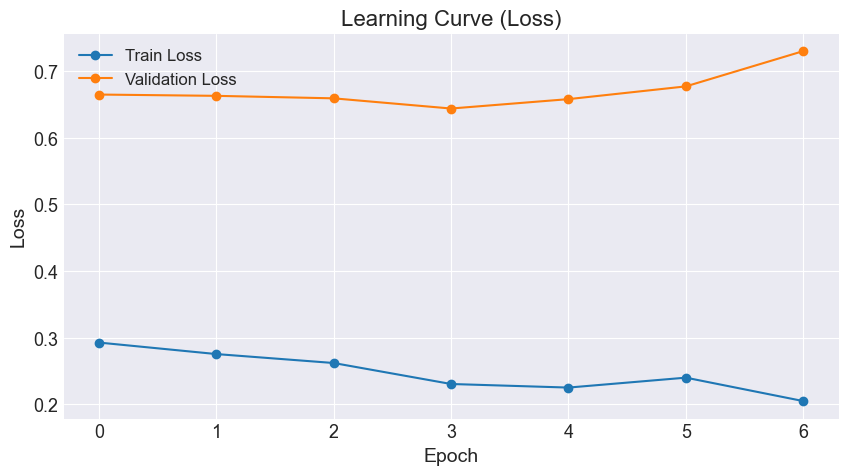

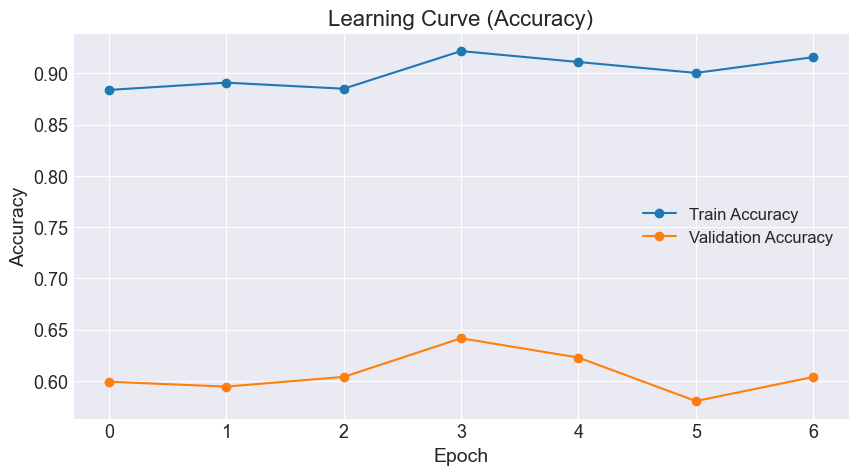

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Learning Curve (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


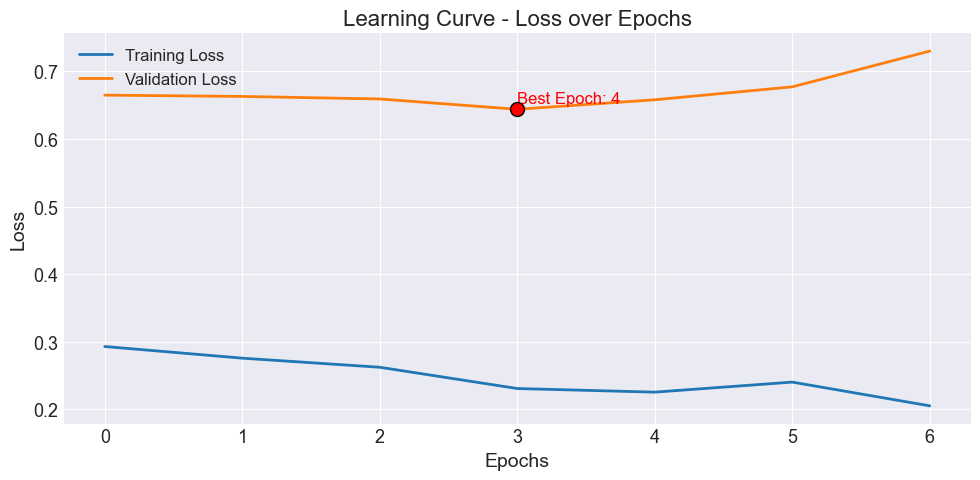

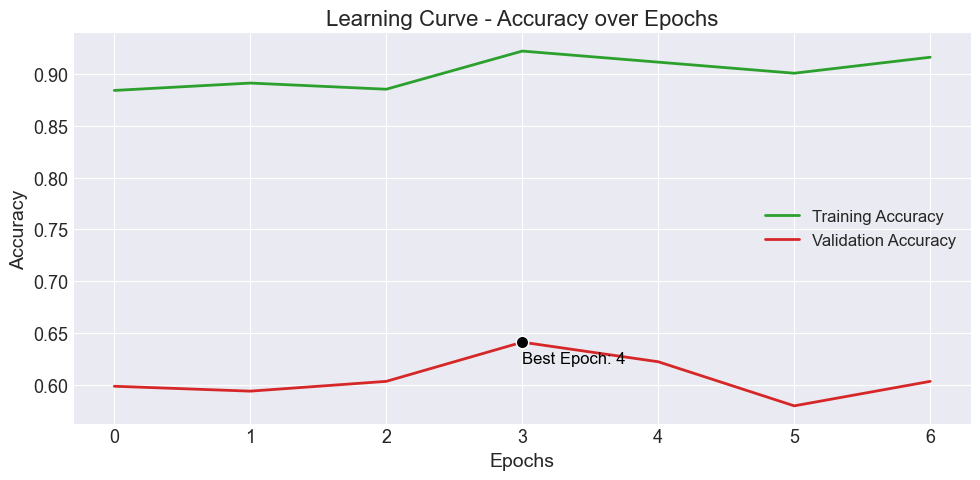

In [60]:
import matplotlib.pyplot as plt
import numpy as np

best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
best_val_acc = history.history['val_accuracy'][best_epoch]

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'figure.figsize': (10,5)
})

# Loss 
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)

plt.scatter(best_epoch, best_val_loss, color='red', s=100, edgecolors='k', zorder=5)
plt.text(best_epoch, best_val_loss+0.01, f'Best Epoch: {best_epoch+1}', color='red', fontsize=12)

plt.title('Learning Curve - Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy 
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)

plt.scatter(best_epoch, best_val_acc, color='black', s=80, edgecolors='white', zorder=5)
plt.text(best_epoch, best_val_acc-0.02, f'Best Epoch: {best_epoch+1}', color='black', fontsize=12)

plt.title('Learning Curve - Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


7/7 [==============================] - 1s 7ms/step


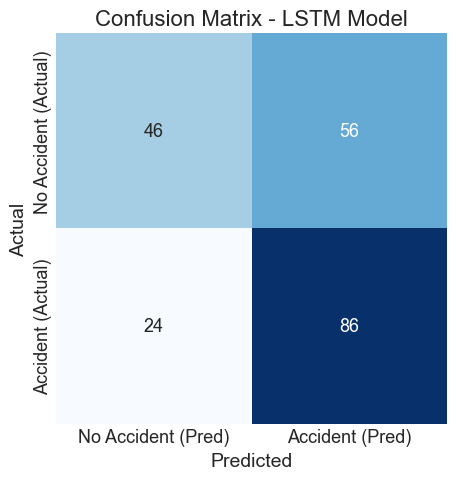


 Classification Report:

              precision    recall  f1-score   support

 No Accident       0.66      0.45      0.53       102
    Accident       0.61      0.78      0.68       110

    accuracy                           0.62       212
   macro avg       0.63      0.62      0.61       212
weighted avg       0.63      0.62      0.61       212



In [61]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


best_model_path = r"E:\nexar_dataset\models\best_lstm_model.h5"

best_model = load_model(best_model_path)

y_pred_probs = best_model.predict(X_val_lstm)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
            xticklabels=['No Accident (Pred)', 'Accident (Pred)'],
            yticklabels=['No Accident (Actual)', 'Accident (Actual)'])
plt.title('Confusion Matrix - LSTM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# precision, recall, f1-score
print("\n Classification Report:\n")
print(classification_report(y_val, y_pred, target_names=['No Accident', 'Accident']))
